# Profile measurements with AP shapes
>  To measure SB profiles after placing AP inferred shapes on a cluster image and comparing with the AP iinferred SB profile

In [1]:
# | default_exp euclid.mask

In [2]:
# | exporti
import pandas as pd 

import glob
from pathlib import Path
import numpy as np

import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.stats import sigma_clip
from astropy.coordinates import SkyCoord
from astropy.nddata import CCDData

from nicl.mask import (
    create_bcg_mask,
    create_icl_mask,
    create_faint_mask,
    create_object_mask,
)
from nicl.utilities import (
    calc_sb_threshold as _calc_sb_threshold,
    get_pixel_scale,
    sb_to_adu,
)

In [3]:
# | hide

import logging

import matplotlib.pyplot as plt


from nicl.main import configure_logging
from nicl.mask import plot_mask

import importlib.util
import sys
import os
import traceback
from textwrap import dedent

import autoprof
from autoprof import Pipeline 

from photutils.aperture import EllipticalAnnulus, CircularAnnulus
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle

from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import FlatLambdaCDM
h=0.7
cosmo=FlatLambdaCDM(H0=h*100, Om0=0.3)

In [4]:
# | exporti
plt.style.use("nicl.euclid.v1nicl")
configure_logging(name="nicl.euclid.mask", level="DEBUG")
configure_logging(name="nicl.mask", level="DEBUG")

<Logger nicl.mask (DEBUG)>

In [11]:
######### Parameters below are being called in create_masks

ICL_NSIGMA = 0.5    
ICL_SMOOTH_SIGMA = 50.0
ICL_BKG_BOX_SIZE = 300
ICL_BKG_FILTER_SIZE = 3
ICL_DILATION_RADIUS = 70.0
ICL_MEDIAN_FILTER = True
REGULAR_DETECTION_PARAMS = {
    "nsigma": 3.0,
    "background": 0.0,
    "smooth_sigma": 1.0,
    "npixels": 5,
    "nlevels": 32,
    "contrast": 0.01,
    "bkg_box_size": 200,
    "bkg_filter_size": 3,
}
REGULAR_GROWTH = 0.5
FAINT_DETECTION_PARAMS = {
    "nsigma": 2.0,
    "smooth_sigma": 1.0,
    "npixels": 5,
    "nlevels": 128,
    "contrast": 0.001,
}
FAINT_GROWTH = 0.25
FAINT_BKG_SIGMA = 50.0
NIR_STACK_BKG_BOX_SIZE = 300
NIR_STACK_BKG_FILTER_SIZE = 3

In [12]:
# | exporti

def calc_sb_threshold(
    z,  # cluster redshift
    filter,  # Euclid filter: VIS, Y, J or H
):
    """Determine the ICL surface brightness threshold for a given redshift and Euclid filter."""
    filter = filter.replace("NIR_", "")
    filter = f"Euclid-{filter}.ecsv"
    return _calc_sb_threshold(z, filter)
    
def create_masks(
    image,  # the image to mask, with bad pixels set to NaN, as a CCDImage or filename
    *,  # the following parameters must be provided as keyword arguments if required
    z=None,  # the cluster redshift for the BCG mask; if None then returned BCG mask is None
    filter=None,  # the filter name for the BCG mask; if None then returned BCG mask is None
    centre_pos=None,  # the position of the BCG/cluster centre; set to False for a non-cluster image
    make_faint_mask=True,  # whether to create a separate object mask in the ICL region
    zeropoint="ZPAB",  # the zeropoint, either as a header keyword or numeric value
):
    """Create BCG, ICL, object and faint masks with default settings for Euclid data.

    These default settings are to be refined.
    """
    if isinstance(image, str):
        image = CCDData.read(image, unit="adu")  # unit does not matter
    # === Bad pixels ===
    badpixel_mask = ~np.isfinite(image)
    # === BCG ===
    if centre_pos is not False and z is not None and filter is not None:
        sb_threshold = calc_sb_threshold(z, filter)
        if isinstance(zeropoint, str):
            zp = image.header[zeropoint] * u.ABmag
        else:
            zp = zeropoint * u.ABmag
        sb_adu_threshold = sb_to_adu(sb_threshold, get_pixel_scale(image), zp)
        bcg_mask = create_bcg_mask(
            image.data,
            sb_threshold=sb_adu_threshold,
            centre_pos=centre_pos,
            wcs=image.wcs,
        )
    else:
        bcg_mask = None
    # === ICL ===
    if centre_pos is not False:
        icl_mask, _ = create_icl_mask(
            image.data,
            centre_pos=centre_pos,
            wcs=image.wcs,
            nsigma=ICL_NSIGMA,
            smooth_sigma=ICL_SMOOTH_SIGMA,
            bkg_box_size=ICL_BKG_BOX_SIZE,
            bkg_filter_size=ICL_BKG_FILTER_SIZE,
            dilation_radius=ICL_DILATION_RADIUS,
            median_filter=ICL_MEDIAN_FILTER,
        )
    else:
        icl_mask = None
    # === Regular objects ===
    if make_faint_mask:
        # In this case, we exclude objects under the ICL mask,
        # as these will be included in the faint mask
        object_mask, bkg, threshold, centre_mask = create_object_mask(
            image.data,
            exclude_mask=icl_mask,
            growth=REGULAR_GROWTH,
            detection_params=REGULAR_DETECTION_PARAMS,
        )
    else:
        # In this case, we only exclude the object at the central position
        object_mask, bkg, threshold, centre_mask = create_object_mask(
            image.data,
            exclude_position=centre_pos,
            wcs=image.wcs,
            growth=REGULAR_GROWTH,
            detection_params=REGULAR_DETECTION_PARAMS,
        )
    # === Faint objects (under ICL) ===
    if centre_pos is not False and make_faint_mask:
        faint_mask, faint_bkg, faint_threshold = create_faint_mask(
            image.data,
            include_mask=centre_mask,
            exclude_position=centre_pos,
            wcs=image.wcs,
            growth=FAINT_GROWTH,
            detection_params=FAINT_DETECTION_PARAMS,
            bkg_sigma=FAINT_BKG_SIGMA,
        )
    else:
        faint_mask = None
    output_masks = {
        "badpixel": badpixel_mask,
        "bcg": bcg_mask,
        "icl": icl_mask,
        "object": object_mask,
        "faint": faint_mask,
    }
    return output_masks

# updated to include wcs information while storing masks
def save_masks(
    masks,    # Dictionary of masks returned by create_masks
    output_dir,  
    label=None,   
    reference_header=None 
):
    """Save all masks produced by create_masks to disk."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    prefix = f"{label}_" if label else ""
    for mask_name, mask in masks.items():
        if mask is not None:
            mask = mask.astype(np.uint8)
            output_fn = output_dir / f"{prefix}{mask_name}_mask.fits"
            hdu = fits.PrimaryHDU(data=mask, header=reference_header)
            hdu.writeto(output_fn, overwrite=True)
            print(f"Saved mask: {output_fn}")


In [13]:
# | exporti


def clean_and_process_images_for_autoprof(
    image_directory,
    mode="bulk",
    clusterid=None,
    bands=None,
    nan_value_replace='extreme',
    output_directory=None,
    boxsize=300
):
    """
    Cleans and processes images by replacing NaNs and saving to output directory.
    
    Parameters:
    - imdir (str): Directory where images are located.
    - mode (str): 'bulk' or 'single'. 'bulk' processes all matching images, 'single' targets one cluster.
    - clusterid (str): Required if mode is 'single'.
    - bands (list): List of bands to process. Default is ["H", "J", "Y", "HJY"].
    - nan_value_replace (str): 'extreme' to replace with 99, 'nanmin' to replace with np.nanmin.
    - output_directory (str or Path): Optional path to save cleaned images.
    - boxsize (int): Box size used in filename pattern.
    """
    if bands is None:
        bands = ["H", "J", "Y", "HJY"]

    for band in bands:
        if mode == "single":
            if not clusterid:
                raise ValueError("clusterid must be provided in single mode.")
            # pattern = f"{image_directory}{clusterid}_{band}_BKGSUB_boxsize_{boxsize}.fits"
            pattern = image_directory / f"EUC_NIR_W-STK_{band}-{clusterid}.fits"
            
        elif mode == "bulk":
            pattern = image_directory / f"EUC_NIR_W-STK_{band}-*.fits"
            
        else:
            raise ValueError("mode must be either 'bulk' or 'single'")

        image_files = sorted(glob.glob(str(pattern)))
        
        if not image_files:
            print(f"No files matched pattern: {pattern}")
            continue

        for image in image_files:
            image_path = Path(image)
            print(f"\nProcessing Image: {image_path.name}")
            
            new_clean_image_name = f"cleaned_{image_path.name}"

            with fits.open(image_path) as hdul:
                image_data = hdul[1].data.copy()
                image_header = hdul[1].header.copy()
                nan_mask = np.isnan(image_data)
                print(f"Number of NaN values: {nan_mask.sum()}")

                clean_image_data = image_data.copy()
                if nan_value_replace == 'extreme':
                    print("Replacing NaNs with 99.")
                    clean_image_data[nan_mask] = 99
                elif nan_value_replace == 'nanmin':
                    print("Replacing NaNs with nanmin.")
                    clean_image_data[nan_mask] = np.nanmin(clean_image_data)
                else:
                    raise ValueError("nan_value_replace must be 'extreme' or 'nanmin'.")

            save_dir = Path(output_directory) if output_directory else image_path.parent
            save_path = save_dir / new_clean_image_name
            save_dir.mkdir(parents=True, exist_ok=True)

            fits.writeto(save_path, clean_image_data, header=image_header, overwrite=True)
            print(f"Saved cleaned image to: {save_path}")

In [14]:
# | exporti


def run_autoprof(
    ids,
    image_files,
    mask_files,
    mode = "image list",
    unit_type= "intensity",
    gscale=0.4,
    pixelscale=0.3,
    zeropoint = 23.9,
    out_dir="./",
    config_name="basic_config.py",
    log_path="AutoProf.log",
    fourier_orders = None,
):
    """
    Running AutoProf on given image and mask files with a custom configuration.
    
    Parameters:
    - ids: List of strings for each image
    - image_files: List of paths to the image fits files
    - mask_files: List of paths to the mask fits files
    - mode : "image list" then ids, image and mask files needs to be arrays so it ca run for bulk.
    - unit_type: Either 'intensity' or 'mag'
    - gscale: Geometric scaling factor, default for noise diagnostics is 0.4 ~0.15dex, for clusters 0.1~0.05dex
    - out_dir: Output directory for saving results and logs
    - config_name: Name for the config Python file, so far I only magaed to run this software by calling its "basic_config" ...
      it crashes once this naming change, since it tries to access certain modules associated with it.

    - fourier_orders : To turn on extraction of Fourier coefficients, useful for lopsidedness analysis. I made it optional. Takes in a tuple (1,2,3)
    """
    os.makedirs(out_dir, exist_ok=True)
    
    config_file = os.path.join(out_dir, config_name)
    
    # Write the config file for AP
    with open(config_file, "w") as f:
        f.write(dedent(f"""\
import numpy as np
ap_process_mode = f"{mode}"
ap_name = {ids}
ap_image_file = {image_files}
ap_mask_file = {mask_files}
ap_saveto = "{out_dir}"
ap_pixscale = {pixelscale}
ap_zeropoint = {zeropoint}
ap_samplegeometricscale = {gscale}
ap_doplot = True
ap_extractfull = True
ap_fluxunits = "{unit_type}"
ap_isoclip = True
ap_isoclip_nsigma = 5
ap_ellipsefit = True
ap_fix_pa = False
ap_initial_pa = 45.0 
ap_fix_ellipticity = False
ap_initial_ellipticity = 0.3 
{"ap_iso_measurecoefs = " + str(fourier_orders) if fourier_orders else ""}
ap_new_pipeline_steps = [
    "mask segmentation map",
    "background",
    "psf",
    "center",
    "isophoteinit",
    "isophotefit",
    "isophoteextract",
    "writeprof",
]
"""))
    
    os.chdir(out_dir)   # Need to change the working directory for outputs, diagnostic plots will not be saved properly if this is not applied 


    try:
        import sys
        if config_name.replace(".py", "") in sys.modules:
            del sys.modules[config_name.replace(".py", "")]
        
        PIPELINE = Pipeline.Isophote_Pipeline(loggername=log_path)
        PIPELINE.Process_ConfigFile(config_name.replace(".py", ""))

        print(f"AutoProf completed successfully for {ids}!")
    except Exception as e:
        print(f"AutoProf failed for {ids}. Logging error...")

        error_log_file = Path(out_dir) / f"autoprof_error_{ids[0]}.log"
        with open(error_log_file, "w") as log:
            log.write(f"AutoProf failed for {ids}\n")
            log.write(f"Error type: {type(e).__name__}\n")
            log.write(f"Error message: {str(e)}\n")
            log.write("Full traceback:\n")
            log.write(traceback.format_exc())

        print(f"Error log saved to: {error_log_file}")


In [15]:
# | exporti

def process_cluster_with_autoprof(image_dir, cluster_directory, cluster_ids, filters):
    """
    image_dir: List of directories of the image.fits
    cluster_directory: directory if the cluster where is masks are located. The autoprof_results folder will be created within the respective cluster's directory.
    cluster_id: List of cluster IDs
    filters = list of band filters 
    """
    image_dir = Path(image_dir)
    
    for cluster_id in cluster_ids:
        
        cluster_directory = Path(cluster_directory) / cluster_id
        
        AP_results_dir = cluster_directory / "autoprof_results"
        AP_results_dir.mkdir(parents=True, exist_ok=True)
        
        for filter in filters:
            # Step 1: Clean and prepare image
            clean_and_process_images_for_autoprof(
                image_directory=image_dir,             
                output_directory=AP_results_dir,     
                mode='single',
                clusterid=cluster_id,
                bands=[filter]
            )
        
            cluster_band = f"{cluster_id}_{filter}"
            
            # Step 2: Run AutoProf
            run_autoprof(
                ids=[cluster_band],
                image_files=[str(AP_results_dir / f"cleaned_EUC_NIR_W-STK_{filter}-{cluster_id}.fits")],
                mask_files=[str(cluster_directory / f'{cluster_id}_{filter}_measurement_mask.fits')],
                out_dir=str(AP_results_dir),
                fourier_orders=(1, 4)
            )
            
            # Step 3: Keep only important output files
            files_to_keep = {
                "basic_config.py",
                f"{cluster_band}.prof",
                f"{cluster_band}.aux",
                f"Background_hist_{cluster_band}.jpg",
                f"mask_{cluster_band}.jpg",
                f"initialize_ellipse_{cluster_band}.jpg",
                f"photometry_{cluster_band}.jpg",
            }
            
            # Step 4: Clean up other files
            for f in AP_results_dir.iterdir():
                if f.is_file() and f.name not in files_to_keep:
                    if f"{filter}-{cluster_id}" in f.name or f"{cluster_id}_{filter}" in f.name:
                        try:
                            f.unlink()
                            print(f"Deleted: {f.name}")
                        except Exception as e:
                            print(f"Could not delete {f.name}: {e}")



In [16]:
# | exporti


def Extract_SB_using_AP_shapes(
    image_path, object_mask_path, profile_path, bcg_pos, annuli_shape='elliptical', pixelscale=0.3, 
    core_mask_path=None, rad_limit_annulus=None, verbose=None, num_points=1, output_csv_path=None, 
    show_plot=True, plot_output_path=None, plot_lims=1000):
    
    """
    Compute flux statistics for elliptical or circular annuli centred at a given SkyCoord (bcg_pos).
    """

    profile = pd.read_csv(profile_path, skiprows=1)

    ccd = CCDData.read(image_path, unit="adu")
    image = ccd.data
    wcs = ccd.wcs

    x, y = wcs.world_to_pixel(bcg_pos)

    object_mask = fits.getdata(object_mask_path).astype(bool)

    if core_mask_path is not None:
        core_mask = fits.getdata(core_mask_path).astype(bool)
        combined_mask = object_mask | core_mask | ~np.isfinite(image)
    else:
        combined_mask = object_mask | ~np.isfinite(image)

    masked_image = np.where(combined_mask, np.nan, image)
    image_height, image_width = masked_image.shape

    profile['R'] = profile['R'] / pixelscale  # Convert arcsec to pixels

    if rad_limit_annulus:
        profile = profile[profile['R'] < rad_limit_annulus]

    rad = profile['R'].values
    ellip = profile['ellip'].values
    pa = profile['pa'].values

    selected_annuli = sorted(set(rad))
    flux_stats = []
    problematic_annuli = []
    final_selected_points = []

    final_selected_points.append((x, y))

    for i in range(len(selected_annuli) - 1):
        r_inner = selected_annuli[i]
        r_outer = selected_annuli[i + 1]
        e = ellip[i]
        theta = np.deg2rad(pa[i])

        if annuli_shape == 'circular':
            annulus = CircularAnnulus((x, y), r_in=r_inner, r_out=r_outer)
            
        elif annuli_shape == 'elliptical':
            annulus = EllipticalAnnulus(
                (x, y),
                a_in=r_inner,
                a_out=r_outer,
                b_in=r_inner * (1 - e),
                b_out=r_outer * (1 - e),
                theta= theta-90
            )

        annulus_mask = annulus.to_mask(method='center')
        mask_image = annulus_mask.to_image(masked_image.shape)

        valid_flux_values = masked_image[np.isfinite(masked_image) & (mask_image > 0)]

        total_pixels = np.sum(mask_image > 0)
        total_valid = len(valid_flux_values)
        total_masked = total_pixels - total_valid

        if total_valid == 0:
            problematic_annuli.append({'x': x, 'y': y, 'r_inner': r_inner, 'r_outer': r_outer})
            mean_flux = median_flux = std_flux = np.nan
            clipped_mean_flux = clipped_median_flux = clipped_std_flux = np.nan
        else:
            mean_flux = np.nanmean(valid_flux_values) / (pixelscale**2)
            median_flux = np.nanmedian(valid_flux_values) / (pixelscale**2)
            std_flux = np.nanstd(valid_flux_values) if len(valid_flux_values) > 1 else np.nan

            clipped = sigma_clip(valid_flux_values, sigma=3, cenfunc='median', maxiters=5)
            clipped_valid = clipped.data[~clipped.mask]

            clipped_mean_flux = np.nanmean(clipped_valid) / (pixelscale**2)
            clipped_median_flux = np.nanmedian(clipped_valid) / (pixelscale**2)
            clipped_std_flux = np.nanstd(clipped_valid) if len(clipped_valid) > 1 else np.nan

        flux_stats.append({
            'Centre_pixel': (x, y),
            'Inner_Radius_pix': r_inner,
            'Outer_Radius_pix': r_outer,
            'Inner_Radius_arcsec': r_inner * pixelscale,
            'Outer_Radius_arcsec': r_outer * pixelscale,
            'Radial_Bin_Centre_pix': (r_inner + r_outer) / 2,
            'Mean_flux_annulus': mean_flux,
            'Median_flux_annulus': median_flux,
            'Std_flux_annulus': std_flux,
            'Total_valid_pix_annulus': total_valid,
            'Total_masked_pix_annulus': total_masked,
            'Clipped_mean_flux_annulus': clipped_mean_flux,
            'Clipped_median_flux_annulus': clipped_median_flux,
            'Clipped_Std_flux_annulus': clipped_std_flux,
        })

    if show_plot:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(masked_image, origin='lower', cmap='gray', norm=simple_norm(masked_image, 'sqrt', percent=99))

        for i in range(len(selected_annuli) - 1):
            r_outer = selected_annuli[i + 1]
            e = ellip[i]
            theta = np.deg2rad(pa[i])

            if annuli_shape == 'circular':
                circle = Circle(
                    (x, y),
                    radius=r_outer,
                    edgecolor='blue',
                    facecolor='none',
                    lw=1
                )
                ax.add_patch(circle)
            else:
                ellipse = Ellipse(
                    (x, y),
                    width=2 * r_outer,
                    height=2 * r_outer * (1 - e),
                    angle=np.rad2deg(theta - 90),
                    edgecolor='red',
                    facecolor='none',
                    lw=0.5
                )
                ax.add_patch(ellipse)

        ax.set_title("Annuli Overlay")
        plt.show()

    flux_stats_df = pd.DataFrame(flux_stats)
   

    return flux_stats_df, profile, problematic_annuli


In [17]:
# | exporti

def plot_sb_profile(flux_stats_df, x_column='Outer_Radius_pix', y_column='Median_flux_annulus',
    x_unit='pix',  # or 'arcsec' or 'kpc'
    pixelscale=0.3,  # arcsec/pixel
    redshift=None,  # Used if x_unit='kpc'
    cosmology=cosmo,  # Astropy cosmology object
    x_label=None,
    y_label=None,
    logy=True,
    logx=True,
    figsize=(6, 5),
    color='tab:blue',
    marker='o',
    title=None,
    ax=None,
    save_fig=None,
    plot_dir = None
):

    R = flux_stats_df[x_column]
    Y = flux_stats_df[y_column]

    if x_unit == 'arcsec':
        R = R * pixelscale
        x_label = x_label or 'Radius (arcsec)'

    elif x_unit == 'kpc':
        if redshift is None:
            raise ValueError("To plot in kpc, please provide a redshift.")
        
        arcsec_to_kpc = cosmo.arcsec_per_kpc_proper(redshift)
        
        R = R * pixelscale / arcsec_to_kpc.value
        x_label = x_label or f'Radius (kpc)'

    else:  # 'pix'
        x_label = x_label or 'Radius (pixels)'

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    ax.plot(R, Y, marker=marker, linestyle='-', color=color, label=y_label or y_column)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label or y_column)

    if logy:
        ax.set_yscale('log')
        ax.set_ylim(bottom=1e-5)
    if logx:
        ax.set_xscale('log')

    if title:
        ax.set_title(title)

    ax.legend()
    plt.tight_layout()

    if save_fig:
        plt.savefig( plot_dir / "SB_profile_comarison.pdf", dpi=100)
    return ax

Processing /home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/tutku/EUC_NIR_W-STK_H-1eRASS J035756.9-490001.fits
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/tutku/EUC_NIR_W-STK_H-1eRASS J035756.9-490001.fits 0.6922 59.482200622558594 -48.99893951416016


2025-04-08 15:55:16 - nicl.mask.create_bcg_mask - INFO - Creating BCG mask
2025-04-08 15:55:26 - nicl.mask.create_icl_mask - INFO - Creating ICL mask
2025-04-08 15:55:26 - nicl.mask.create_icl_mask - DEBUG - Estimating background with box size 300 and filter size 3
2025-04-08 15:55:32 - nicl.mask.create_icl_mask - DEBUG - Average 0.5 sigma detection threshold: 0.01031
2025-04-08 15:55:32 - nicl.mask.create_icl_mask - DEBUG - Smoothing image with sigma=50.0
2025-04-08 15:55:32 - nicl.mask.create_icl_mask - DEBUG - Smoothing with a sampled median filter
2025-04-08 15:55:36 - nicl.mask.create_icl_mask - DEBUG - Detecting sources
2025-04-08 15:55:36 - nicl.mask.create_icl_mask - DEBUG - Keeping segment at specified position
2025-04-08 15:55:36 - nicl.mask.create_icl_mask - DEBUG - Creating source mask with dilation radius 70.0
2025-04-08 16:01:43 - nicl.mask.create_icl_mask - INFO - ICL mask created, 62237 pixels masked (0.17%)
2025-04-08 16:01:43 - nicl.mask.create_object_mask - INFO - Cr

Saved mask: /home/ppztk1/Erosita/Outputs_Clusters/1eRASS J035756.9-490001/1eRASS J035756.9-490001_H_background_mask.fits
Saved mask: /home/ppztk1/Erosita/Outputs_Clusters/1eRASS J035756.9-490001/1eRASS J035756.9-490001_H_measurement_mask.fits
Saved mask: /home/ppztk1/Erosita/Outputs_Clusters/1eRASS J035756.9-490001/1eRASS J035756.9-490001_H_icl_mask.fits
Saved mask: /home/ppztk1/Erosita/Outputs_Clusters/1eRASS J035756.9-490001/1eRASS J035756.9-490001_H_bcg_mask.fits
Masking procedure is Completed!

Processing Image: EUC_NIR_W-STK_H-1eRASS J035756.9-490001.fits
Number of NaN values: 183912
Replacing NaNs with 99.
Saved cleaned image to: /home/ppztk1/Erosita/Outputs_Clusters/1eRASS J035756.9-490001/autoprof_results/cleaned_EUC_NIR_W-STK_H-1eRASS J035756.9-490001.fits
1eRASS J035756.9-490001_H: head mask segmentation map at: 0.0 sec
1eRASS J035756.9-490001_H: head background at: 327.9 sec
1eRASS J035756.9-490001_H: head psf at: 399.8 sec
1eRASS J035756.9-490001_H: head center at: 399.8 se

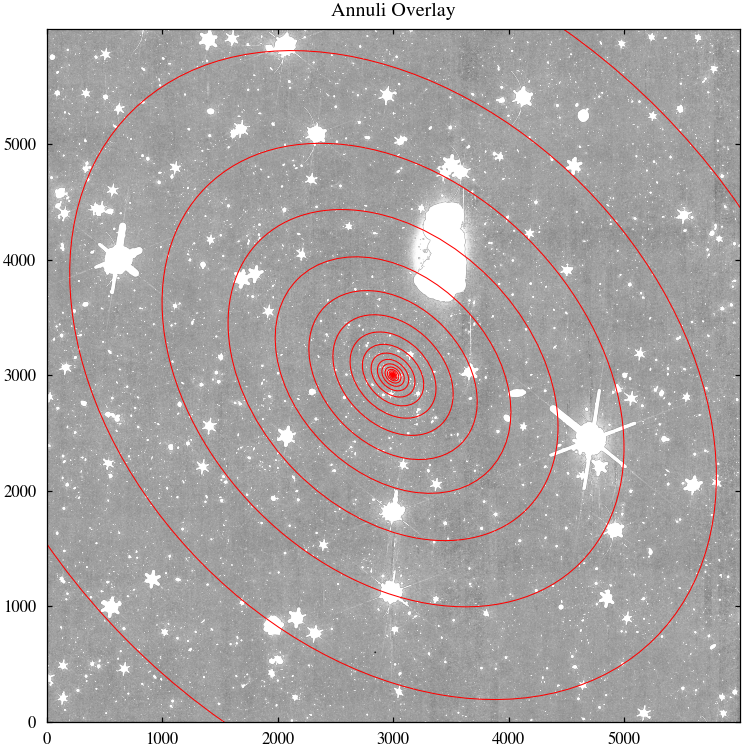

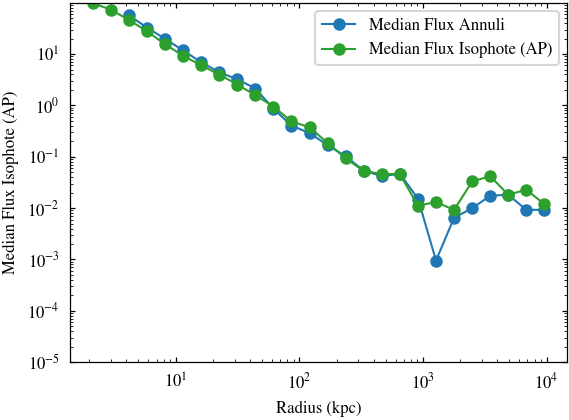

In [19]:
Erass_table = pd.read_csv('/home/ppztk1/Erosita/erosita_2E14_paper.csv') # a table that contains cluster ids and coords and redshifts for easy access
cluster_ids = ["1eRASS J035423.6-475145", "1eRASS J040558.4-491553", "1eRASS J035756.9-490001", "1eRASS J041723.0-474844"]

cluster_ids = ["1eRASS J035756.9-490001"]

for cluster_id in cluster_ids:
        
    cluster_info = Erass_table[Erass_table.NAME==cluster_id].reset_index(drop=True)
    
    image_dir = Path("/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/tutku")
    
    path = Path(image_dir)
    
    filters = ["H"]

    for filter in filters:
    
        fn = path / f"EUC_NIR_W-STK_{filter}-{cluster_id}.fits"
        
        print(f'Processing {fn}')
        
        image = CCDData.read(fn, unit="adu")
        
        cluster_z = cluster_info.BEST_Z[0]
        
        bcg_pos = SkyCoord(cluster_info.RA_BCG[0] * u.deg, cluster_info.DEC_BCG[0] * u.deg, frame="icrs")
    
        print(fn, cluster_z, cluster_info.RA_BCG[0],cluster_info.DEC_BCG[0])
        
        ##### MASKING
        masks = create_masks(
            image,
            z=cluster_z,
            filter=filter,
            centre_pos=bcg_pos,
            make_faint_mask=True,
            zeropoint="ZPAB",
        )
        
        masks["background"] = masks["badpixel"] | masks["icl"] | masks["object"]
        masks["measurement"] = masks["badpixel"] | masks["object"] | masks["faint"]
        
        
        wcs_header = image.wcs.to_header()
        combined_header = image.meta.copy()
        combined_header.update(wcs_header)
        
        outdir = Path(f'/home/ppztk1/Erosita/Outputs_Clusters/')
        
        selected_masks = {k: masks[k] for k in ["background", "measurement", 'icl', 'bcg']}
        save_masks(selected_masks, outdir/cluster_id, reference_header=combined_header, label=f"{cluster_id}_{filter}") 
    
        # plot_mask(image, mask_for_background, detail=False)
        # plot_mask(image, mask_for_measurement, detail=True)
        
        print("Masking procedure is Completed!")    
        
        process_cluster_with_autoprof(image_dir=image_dir, cluster_directory=outdir, cluster_ids=[cluster_id], filters=[filter])

        mask_dir = outdir / cluster_id / f"{cluster_id}_{filter}_measurement_mask.fits"
        prof_dir = outdir / cluster_id / "autoprof_results" / f"{cluster_id}_{filter}.prof"
        flux_measurements, profile, problematic_annuli = Extract_SB_using_AP_shapes(image_path=fn, object_mask_path=mask_dir, profile_path=prof_dir, bcg_pos=bcg_pos)

        fig, ax = plt.subplots(1,1)
        plot_sb_profile(flux_measurements, 'Outer_Radius_pix', 'Median_flux_annulus',  x_unit='kpc', redshift=cluster_z, y_label='Median Flux Annuli', ax=ax)
        plot_sb_profile(profile, x_column = 'R',  y_column='I', x_unit='kpc', redshift=cluster_z,  y_label='Median Flux Isophote (AP)', ax=ax,color='tab:green')
        plt.savefig(outdir/cluster_id/"SB_comparisons.pdf")

        
        


In [ ]:
# import numpy as np
# import pandas as pd
# import glob
# from astropy.io import fits
# from astropy.nddata import CCDData
# from astropy.wcs import WCS
# from astropy.visualization import simple_norm
# import astropy.units as u
# from astropy.stats import sigma_clip

# from photutils.aperture import EllipticalAnnulus, CircularAnnulus
# import matplotlib.pyplot as plt
# from matplotlib.patches import Ellipse, Circle

# from astropy.cosmology import Planck18 as cosmo
# from astropy.cosmology import FlatLambdaCDM
# h=0.7
# cosmo=FlatLambdaCDM(H0=h*100, Om0=0.3)


# def Extract_SB_using_AP_shapes(
#     image_path, object_mask_path, profile_path, bcg_pos, annuli_shape='elliptical', pixelscale=0.3, 
#     core_mask_path=None, rad_limit_annulus=None, verbose=None, num_points=1, output_csv_path=None, 
#     show_plot=True, plot_output_path=None, plot_lims=1000):
    
#     """
#     Compute flux statistics for elliptical or circular annuli centred at a given SkyCoord (bcg_pos).
#     """

#     profile = pd.read_csv(profile_path, skiprows=1)

#     ccd = CCDData.read(image_path, unit="adu")
#     image = ccd.data
#     wcs = ccd.wcs

#     x, y = wcs.world_to_pixel(bcg_pos)

#     object_mask = fits.getdata(object_mask_path).astype(bool)

#     if core_mask_path is not None:
#         core_mask = fits.getdata(core_mask_path).astype(bool)
#         combined_mask = object_mask | core_mask | ~np.isfinite(image)
#     else:
#         combined_mask = object_mask | ~np.isfinite(image)

#     masked_image = np.where(combined_mask, np.nan, image)
#     image_height, image_width = masked_image.shape

#     profile['R'] = profile['R'] / pixelscale  # Convert arcsec to pixels

#     if rad_limit_annulus:
#         profile = profile[profile['R'] < rad_limit_annulus]

#     rad = profile['R'].values
#     ellip = profile['ellip'].values
#     pa = profile['pa'].values

#     selected_annuli = sorted(set(rad))
#     flux_stats = []
#     problematic_annuli = []
#     final_selected_points = []

#     final_selected_points.append((x, y))

#     for i in range(len(selected_annuli) - 1):
#         r_inner = selected_annuli[i]
#         r_outer = selected_annuli[i + 1]
#         e = ellip[i]
#         theta = np.deg2rad(pa[i])

#         if annuli_shape == 'circular':
#             annulus = CircularAnnulus((x, y), r_in=r_inner, r_out=r_outer)
            
#         elif annuli_shape == 'elliptical':
#             annulus = EllipticalAnnulus(
#                 (x, y),
#                 a_in=r_inner,
#                 a_out=r_outer,
#                 b_in=r_inner * (1 - e),
#                 b_out=r_outer * (1 - e),
#                 theta= theta-90
#             )

#         annulus_mask = annulus.to_mask(method='center')
#         mask_image = annulus_mask.to_image(masked_image.shape)

#         valid_flux_values = masked_image[np.isfinite(masked_image) & (mask_image > 0)]

#         total_pixels = np.sum(mask_image > 0)
#         total_valid = len(valid_flux_values)
#         total_masked = total_pixels - total_valid

#         if total_valid == 0:
#             problematic_annuli.append({'x': x, 'y': y, 'r_inner': r_inner, 'r_outer': r_outer})
#             mean_flux = median_flux = std_flux = np.nan
#             clipped_mean_flux = clipped_median_flux = clipped_std_flux = np.nan
#         else:
#             mean_flux = np.nanmean(valid_flux_values) / (pixelscale**2)
#             median_flux = np.nanmedian(valid_flux_values) / (pixelscale**2)
#             std_flux = np.nanstd(valid_flux_values) if len(valid_flux_values) > 1 else np.nan

#             clipped = sigma_clip(valid_flux_values, sigma=3, cenfunc='median', maxiters=5)
#             clipped_valid = clipped.data[~clipped.mask]

#             clipped_mean_flux = np.nanmean(clipped_valid) / (pixelscale**2)
#             clipped_median_flux = np.nanmedian(clipped_valid) / (pixelscale**2)
#             clipped_std_flux = np.nanstd(clipped_valid) if len(clipped_valid) > 1 else np.nan

#         flux_stats.append({
#             'Centre_pixel': (x, y),
#             'Inner_Radius_pix': r_inner,
#             'Outer_Radius_pix': r_outer,
#             'Inner_Radius_arcsec': r_inner * pixelscale,
#             'Outer_Radius_arcsec': r_outer * pixelscale,
#             'Radial_Bin_Centre_pix': (r_inner + r_outer) / 2,
#             'Mean_flux_annulus': mean_flux,
#             'Median_flux_annulus': median_flux,
#             'Std_flux_annulus': std_flux,
#             'Total_valid_pix_annulus': total_valid,
#             'Total_masked_pix_annulus': total_masked,
#             'Clipped_mean_flux_annulus': clipped_mean_flux,
#             'Clipped_median_flux_annulus': clipped_median_flux,
#             'Clipped_Std_flux_annulus': clipped_std_flux,
#         })

#     if show_plot:
#         fig, ax = plt.subplots(figsize=(6, 6))
#         ax.imshow(masked_image, origin='lower', cmap='gray', norm=simple_norm(masked_image, 'sqrt', percent=99))

#         for i in range(len(selected_annuli) - 1):
#             r_outer = selected_annuli[i + 1]
#             e = ellip[i]
#             theta = np.deg2rad(pa[i])

#             if annuli_shape == 'circular':
#                 circle = Circle(
#                     (x, y),
#                     radius=r_outer,
#                     edgecolor='blue',
#                     facecolor='none',
#                     lw=1
#                 )
#                 ax.add_patch(circle)
#             else:
#                 ellipse = Ellipse(
#                     (x, y),
#                     width=2 * r_outer,
#                     height=2 * r_outer * (1 - e),
#                     angle=np.rad2deg(theta - 90),
#                     edgecolor='red',
#                     facecolor='none',
#                     lw=0.5
#                 )
#                 ax.add_patch(ellipse)

#         ax.set_title("Annuli Overlay")
#         plt.show()

#     flux_stats_df = pd.DataFrame(flux_stats)
   

#     return flux_stats_df, profile, problematic_annuli


In [ ]:
# Erass_table = pd.read_csv('/home/ppztk1/Erosita/erosita_2E14_paper.csv') # a table that contains cluster ids and coords and redshifts for easy access
# # cluster_ids = ["1eRASS J035423.6-475145", "1eRASS J040558.4-491553", "1eRASS J035756.9-490001", "1eRASS J041723.0-474844"]

# cluster_ids = ["1eRASS J035423.6-475145"]

# for cluster_id in cluster_ids:
        
#     cluster_info = Erass_table[Erass_table.NAME==cluster_id].reset_index(drop=True)
    
#     image_dir = Path("/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/tutku")
    
#     path = Path(image_dir)
    
#     filters = ["H"]

#     for filter in filters:
    
#         fn = path / f"EUC_NIR_W-STK_{filter}-{cluster_id}.fits"
        
#         print(f'Processing {fn}')
        
#         image = CCDData.read(fn, unit="adu")
        
#         cluster_z = cluster_info.BEST_Z[0]
        
#         bcg_pos = SkyCoord(cluster_info.RA_BCG[0] * u.deg, cluster_info.DEC_BCG[0] * u.deg, frame="icrs")

#         cluster_directory = Path('/home/ppztk1/Erosita/Outputs_Clusters/')
        
#         mask_dir = cluster_directory / cluster_id / f"{cluster_id}_{filter}_measurement_mask.fits"
#         prof_dir = cluster_directory / cluster_id / "autoprof_results" / f"{cluster_id}_{filter}.prof"
#         flux_measurements, profile, problematic_annuli = Extract_SB_using_AP_shapes(image_path=fn, object_mask_path=mask_dir, profile_path=prof_dir, bcg_pos=bcg_pos)

#         fig, ax = plt.subplots(1,1)
#         plot_sb_profile(flux_measurements, 'Outer_Radius_pix', 'Median_flux_annulus',  x_unit='kpc', redshift=cluster_z, y_label='Median Flux Annuli', ax=ax)
#         plot_sb_profile(profile, x_column = 'R',  y_column='I', x_unit='kpc', redshift=cluster_z,  y_label='Median Flux Isophote (AP)', ax=ax,color='tab:green')
#         plt.savefig(cluster_directory/cluster_id/"SB_comparisons.pdf")

        


<Axes: xlabel='Radius (kpc)', ylabel='Median Flux Isophote (AP)'>

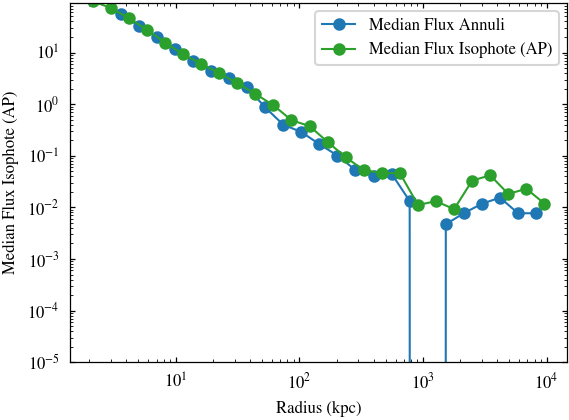

In [25]:
fig, ax = plt.subplots(1,1)

plot_sb_profile(flux_measurements, 'Radial_Bin_Centre_pix', 'Clipped_median_flux_annulus',  x_unit='kpc', redshift=cluster_z, y_label='Median Flux Annuli', ax=ax, logx=True )
plot_sb_profile(profile, x_column = 'R',  y_column='I', x_unit='kpc', redshift=cluster_z,  y_label='Median Flux Isophote (AP)', ax=ax,color='tab:green', logx=True)

# plt.savefig(cluster_directory/cluster_id/"SB_comparisons.pdf")


